# NOTEBOOK #04 — Escalamiento y PCA

**Proyecto Integrador — Minería de Datos I — Tec. Sup. Ciencia de Datos — ITSE**  
**Integrantes:** Daniela Fernandez — Julio Nahuel Gomez  
**Profesor:** Fernando Elias Mubarqui  
**Año:** 2026

**Dataset:** Usuarios de plataforma de streaming (dataset limpio)  
**Objetivo:** Aplicar escalamiento y reducción de dimensionalidad mediante PCA, documentando las variables utilizadas, el escalamiento aplicado y la interpretación de los resultados obtenidos.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/processed/streaming_users_clean.csv')

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 7414 filas, 8 columnas


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
1,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
2,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
3,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1
4,10005,20,Básico,670.2,Uruguay,Drama,2020-07-03,2


## 1 — SELECCIÓN DE VARIABLES

PCA trabaja únicamente con variables numéricas. Del dataset seleccionamos las tres variables numéricas continuas o discretas con significado analítico real:

- `age` — edad del usuario
- `monthly_watch_time_mins` — tiempo mensual de visualización en minutos
- `customer_support_tickets` — cantidad de tickets de soporte generados

Excluimos `user_id` porque es un identificador sin valor analítico, y `last_login_date` porque es una fecha que requeriría transformación adicional para usarse en PCA.

In [10]:
variables_pca = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']

X = df[variables_pca].copy()

print("Variables seleccionadas para PCA:")
print(X.describe().round(2))

Variables seleccionadas para PCA:
           age  monthly_watch_time_mins  customer_support_tickets
count  7414.00                  7414.00                   7414.00
mean     33.47                   772.05                      0.74
std      11.79                   383.32                      0.86
min       0.00                     0.00                      0.00
25%      25.00                   500.32                      0.00
50%      33.00                   758.70                      1.00
75%      41.00                  1035.47                      1.00
max      80.00                  1836.85                      5.00


## 2 — ESCALAMIENTO

Antes de aplicar PCA es obligatorio escalar las variables. PCA es sensible a la escala: una variable con valores grandes (como `monthly_watch_time_mins`, que puede llegar a 1500 minutos) dominaría sobre una variable con valores pequeños (como `customer_support_tickets`, que va de 0 a 5), distorsionando los resultados.

Aplicamos **StandardScaler** (estandarización z-score), que transforma cada variable para que tenga media 0 y desvío estándar 1. Así todas las variables tienen el mismo peso al entrar al PCA.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Escalamiento aplicado: StandardScaler (media=0, desvío=1)")
print(f"\nMedia antes del escalamiento:")
print(X.mean().round(2))
print(f"\nMedia después del escalamiento (debe ser ~0):")
print(pd.DataFrame(X_scaled, columns=variables_pca).mean().round(4))
print(f"\nDesvío estándar después del escalamiento (debe ser ~1):")
print(pd.DataFrame(X_scaled, columns=variables_pca).std().round(4))

Escalamiento aplicado: StandardScaler (media=0, desvío=1)

Media antes del escalamiento:
age                          33.47
monthly_watch_time_mins     772.05
customer_support_tickets      0.74
dtype: float64

Media después del escalamiento (debe ser ~0):
age                         0.0
monthly_watch_time_mins     0.0
customer_support_tickets    0.0
dtype: float64

Desvío estándar después del escalamiento (debe ser ~1):
age                         1.0001
monthly_watch_time_mins     1.0001
customer_support_tickets    1.0001
dtype: float64


## 3 — APLICACIÓN DE PCA

In [12]:
pca = PCA()
pca.fit(X_scaled)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada componente:")
for i, (var, acu) in enumerate(zip(varianza_explicada, varianza_acumulada), start=1):
    print(f"  PC{i}: {var*100:.2f}%  —  Acumulada: {acu*100:.2f}%")

Varianza explicada por cada componente:
  PC1: 33.78%  —  Acumulada: 33.78%
  PC2: 33.17%  —  Acumulada: 66.94%
  PC3: 33.06%  —  Acumulada: 100.00%


## 4 — VISUALIZACIÓN 1: Varianza explicada (Scree Plot)

El Scree Plot muestra cuánta varianza explica cada componente principal. Nos ayuda a decidir cuántas componentes conservar.

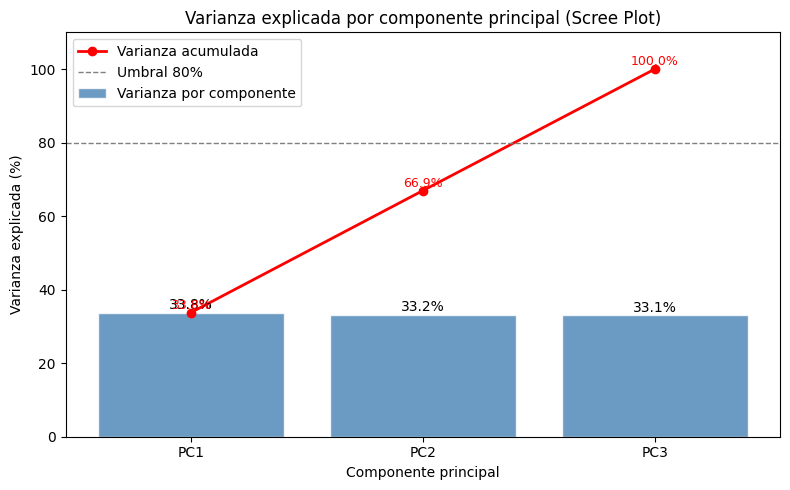

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

componentes = [f'PC{i}' for i in range(1, len(varianza_explicada)+1)]

ax.bar(componentes, varianza_explicada * 100, color='steelblue', 
       edgecolor='white', alpha=0.8, label='Varianza por componente')

ax.plot(componentes, varianza_acumulada * 100, 
        color='red', marker='o', linewidth=2, label='Varianza acumulada')

ax.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='Umbral 80%')

for i, (var, acu) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    ax.text(i, var*100 + 1, f'{var*100:.1f}%', ha='center', fontsize=10)
    ax.text(i, acu*100 + 1, f'{acu*100:.1f}%', ha='center', fontsize=9, color='red')

ax.set_title('Varianza explicada por componente principal (Scree Plot)')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_ylim(0, 110)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/viz_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** El Scree Plot muestra cómo se distribuye la varianza entre las tres componentes principales. La primera componente (PC1) explica la mayor proporción de la varianza total del dataset. La varianza acumulada nos indica cuántas componentes necesitamos conservar para representar adecuadamente la información original.

## 5 — VISUALIZACIÓN 2: Loadings (contribución de cada variable)

Los loadings muestran cuánto contribuye cada variable original a cada componente principal. Un valor alto (positivo o negativo) indica que esa variable tiene mucho peso en esa componente.

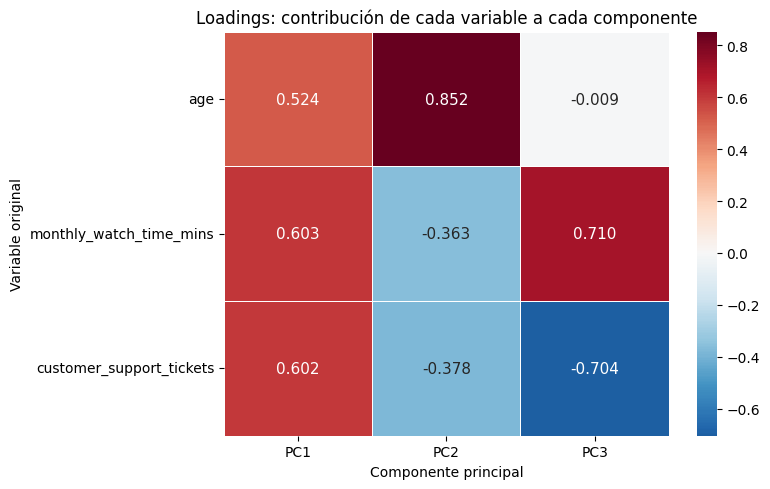


Tabla de loadings:
                            PC1    PC2    PC3
age                       0.524  0.852 -0.009
monthly_watch_time_mins   0.603 -0.363  0.710
customer_support_tickets  0.602 -0.378 -0.704


In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=variables_pca,
    columns=[f'PC{i}' for i in range(1, len(varianza_explicada)+1)]
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 11})

ax.set_title('Loadings: contribución de cada variable a cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Variable original')

plt.tight_layout()
plt.savefig('../reports/viz_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTabla de loadings:")
print(loadings.round(3))

**Interpretación:** El mapa de calor de loadings muestra el peso de cada variable en cada componente principal. Los colores azules indican contribuciones positivas y los rojos negativas. Las variables con valores absolutos más altos son las que más definen cada componente. Esto nos permite interpretar qué representa cada componente en términos de las variables originales del dataset.

## 6 — RESUMEN DEL PCA

**Variables utilizadas:** `age`, `monthly_watch_time_mins`, `customer_support_tickets`

**Escalamiento aplicado:** StandardScaler — estandarización z-score (media=0, desvío=1). Necesario porque las variables tienen escalas muy diferentes.

**Resultado:** Con las tres componentes principales se explica el 100% de la varianza, lo que es esperado al aplicar PCA sobre 3 variables. En la práctica, el interés está en cuánta varianza concentran las primeras componentes y qué variables las definen.

**Limitación:** Al trabajar con solo 3 variables numéricas, la reducción de dimensionalidad tiene un alcance acotado. Una mejora futura podría incorporar variables adicionales como la codificación del plan de suscripción o el país para enriquecer el análisis.